In [ ]:
# ==============================================================================
# Script:           evaluate_betaVAE_revised.py
# Purpose:          Post-training evaluation of BetaVAE latent space quality.
#                   Evaluates reconstruction, latent structure, biological
#                   organisation, and within-sample hypo/hypermethylation
#                   architecture using PCA, UMAP, and HDBSCAN.
#                   Intended to be converted into a Jupyter notebook.
# Author:           Sophia Li
# Affiliation:      CCG Lab, Princess Margaret Cancer Center, UHN, UofT
# ==============================================================================

# 0. Imports and Setup

In [1]:
import numpy as np
import pandas as pd
import torch
import anndata as ad
import scipy.sparse as sp
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import seaborn as sns

import umap
import hdbscan
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    silhouette_score,
    adjusted_rand_score,
    adjusted_mutual_info_score,
)
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_distances
from scipy.stats import spearmanr

import warnings
import sys
from pathlib import Path

warnings.filterwarnings("ignore", category=UserWarning)

project_root = Path.cwd().parent
sys.path.append(str(project_root / "src"))

from MethylCDM.models.betaVAE import BetaVAE

/home/campbell/sophiali/miniforge3/envs/methylcdm-env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Plotting defaults
plt.rcParams.update(
    {
        "figure.dpi": 150,
        "font.size": 11,
        "axes.spines.top": False,
        "axes.spines.right": False,
    }
)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

CHECKPOINT_PATH = "/ddn_exa/campbell/sli/methylcdm-project/betaVAE_train_20260326_175018/best-epoch=152-val_loss=1.5184.ckpt"
VAL_ADATA_PATH  = "/ddn_exa/campbell/sli/methylcdm-project/data/training/methylation/pancancer_val_adata.h5ad"
TEST_ADATA_PATH = "/ddn_exa/campbell/sli/methylcdm-project/data/training/methylation/pancancer_test_adata.h5ad"

OUTPUT_DIR = Path("pancancer_train_run")
OUTPUT_DIR.mkdir(exist_ok=True)

# Methylation thresholds (M-value space): M > HYPER_THRESH = hypermethylated
HYPO_THRESH  = -2.0
HYPER_THRESH =  2.0

# 1. Load Model and Data

In [3]:
model = BetaVAE.load_from_checkpoint(CHECKPOINT_PATH, map_location=DEVICE)
model.eval()
model.to(DEVICE)

val_adata  = ad.read_h5ad(VAL_ADATA_PATH)
test_adata = ad.read_h5ad(TEST_ADATA_PATH)

In [4]:
def adata_to_tensor(adata):
    X = adata.X
    if sp.issparse(X):
        X = X.toarray()
    return torch.tensor(X, dtype=torch.float32).to(DEVICE)

X_val  = adata_to_tensor(val_adata)
X_test = adata_to_tensor(test_adata)

In [13]:
test_path = "/ddn_exa/campbell/sli/methylcdm-project/data/training/methylation/pancancer_cohort_adata.h5ad"
test = ad.read_h5ad(test_path)
test.shape

(5368, 169747)

In [14]:
train_path = "/ddn_exa/campbell/sli/methylcdm-project/data/training/methylation/pancancer_train_adata.h5ad"
train = ad.read_h5ad(train_path)
train.shape

(3435, 169747)

In [5]:
meta_val  = val_adata.obs.copy()
meta_test = test_adata.obs.copy()

meta_val["cancer_type"]  = meta_val["project_id"].str.replace("TCGA-", "")
meta_test["cancer_type"] = meta_test["project_id"].str.replace("TCGA-", "")

print(f"Val shape:  {X_val.shape}")
print(f"Test shape: {X_test.shape}")
print(f"Val cancer types ({meta_val['cancer_type'].nunique()}): "
      f"{sorted(meta_val['cancer_type'].unique())}")
print(f"\nModel: {CHECKPOINT_PATH}")
print(f"Latent dim: {model.hparams.latent_dim}")

Val shape:  torch.Size([859, 169747])
Test shape: torch.Size([1074, 169747])
Val cancer types (14): ['BLCA', 'BRCA', 'GBM', 'HNSC', 'KIRC', 'LGG', 'LIHC', 'LUAD', 'LUSC', 'PAAD', 'PRAD', 'SKCM', 'THCA', 'UCEC']

Model: /ddn_exa/campbell/sli/methylcdm-project/models/beta_vae/betaVAE_sweep_20260320_172129/trial_59/best-epoch=153-val_loss=1.5184.ckpt
Latent dim: 70


# 2. Raw Data Distribution

In [6]:
for adata, label in [(val_adata, "val"), (test_adata, "test")]:
    X = adata.X.data if sp.issparse(adata.X) else adata.X
    print(f"\n--- {label} ---")
    print(f"  Min:         {X.min():.4f}")
    print(f"  Max:         {X.max():.4f}")
    print(f"  Mean:        {X.mean():.4f}")
    print(f"  Std:         {X.std():.4f}")
    print(f"  1st pctile:  {np.percentile(X, 1):.4f}")
    print(f"  99th pctile: {np.percentile(X, 99):.4f}")


--- val ---
  Min:         -19.9316
  Max:         19.9125
  Mean:        -0.1590
  Std:         4.5844
  1st pctile:  -9.9643
  99th pctile: 9.9644

--- test ---
  Min:         -19.9316
  Max:         19.9125
  Mean:        -0.2125
  Std:         4.5857
  1st pctile:  -9.9643
  99th pctile: 9.9644


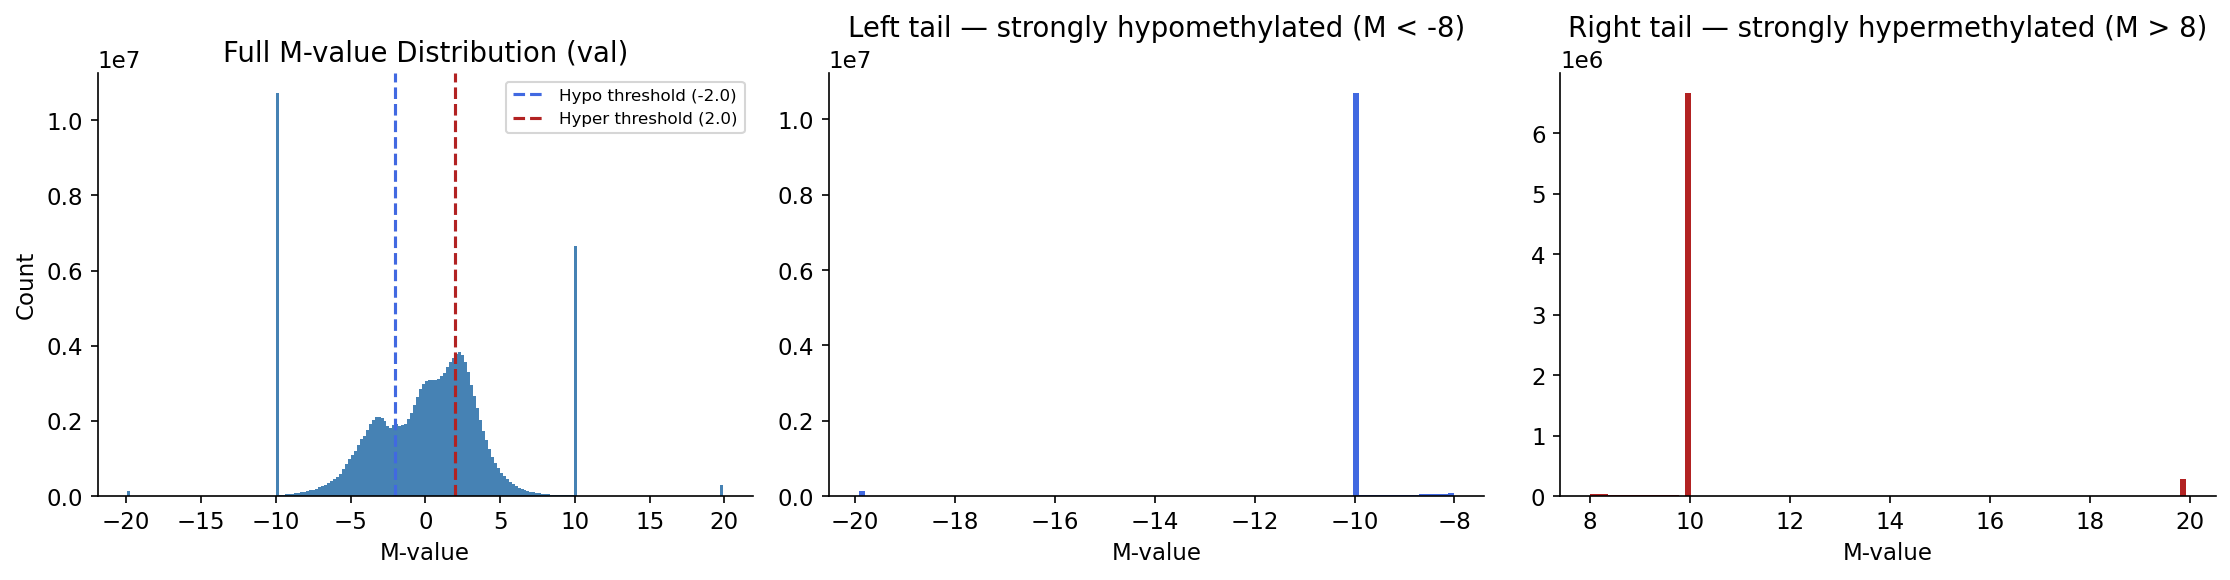

Hypo  (M < -2.0):  30.3% of probes
Hyper (M > 2.0): 31.6% of probes
Intermediate:              38.1% of probes


In [7]:
X_flat = val_adata.X.data if sp.issparse(val_adata.X) else val_adata.X.flatten()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(X_flat, bins=200, color="steelblue", edgecolor="none")
axes[0].axvline(HYPO_THRESH,  color="royalblue",   linestyle="--",
                label=f"Hypo threshold ({HYPO_THRESH})")
axes[0].axvline(HYPER_THRESH, color="firebrick",   linestyle="--",
                label=f"Hyper threshold ({HYPER_THRESH})")
axes[0].set_xlabel("M-value")
axes[0].set_ylabel("Count")
axes[0].set_title("Full M-value Distribution (val)")
axes[0].legend(fontsize=8)

axes[1].hist(X_flat[X_flat < -8], bins=100, color="royalblue", edgecolor="none")
axes[1].set_xlabel("M-value")
axes[1].set_title("Left tail — strongly hypomethylated (M < -8)")

axes[2].hist(X_flat[X_flat > 8], bins=100, color="firebrick", edgecolor="none")
axes[2].set_xlabel("M-value")
axes[2].set_title("Right tail — strongly hypermethylated (M > 8)")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "mvalue_distribution.png")
plt.show()

print(f"Hypo  (M < {HYPO_THRESH}):  {(X_flat < HYPO_THRESH).mean()*100:.1f}% of probes")
print(f"Hyper (M > {HYPER_THRESH}): {(X_flat > HYPER_THRESH).mean()*100:.1f}% of probes")
print(f"Intermediate:              "
      f"{((X_flat >= HYPO_THRESH) & (X_flat <= HYPER_THRESH)).mean()*100:.1f}% of probes")

In [8]:
# Per-probe and per-sample extent of extreme values
X_dense = val_adata.X.toarray() if sp.issparse(val_adata.X) else val_adata.X
probe_max  = np.abs(X_dense).max(axis=0)
sample_max = np.abs(X_dense).max(axis=1)

print(f"\nProbes  with max |M| > 15:  {(probe_max > 15).sum():,} / {len(probe_max):,}")
print(f"Samples with max |M| > 15:  {(sample_max > 15).sum():,} / {len(sample_max):,}")


Probes  with max |M| > 15:  89,795 / 169,747
Samples with max |M| > 15:  19 / 859


# 3. Extract Latent Embeddings and Reconstructions

`z_mu` (posterior mean) is used throughout — it is the deterministic
representation passed to the downstream diffusion model. Reparameterised
samples are not used for evaluation.

In [9]:
with torch.no_grad():
    z_mu_val,  z_logvar_val,  _ = model.encode(X_val)
    z_mu_test, z_logvar_test, _ = model.encode(X_test)
    x_hat_val  = model.decode(z_mu_val)
    x_hat_test = model.decode(z_mu_test)

z_mu_val      = z_mu_val.cpu().numpy()
z_mu_test     = z_mu_test.cpu().numpy()
z_logvar_val  = z_logvar_val.cpu().numpy()
z_logvar_test = z_logvar_test.cpu().numpy()
x_hat_val     = x_hat_val.cpu().numpy()
x_hat_test    = x_hat_test.cpu().numpy()
X_val_np      = X_val.cpu().numpy()
X_test_np     = X_test.cpu().numpy()

print(f"Embedding shape (val):  {z_mu_val.shape}")
print(f"Embedding shape (test): {z_mu_test.shape}")

RuntimeError: mat1 and mat2 shapes cannot be multiplied (859x169747 and 225410x2048)

# 4. Reconstruction Quality

Per-sample Pearson r between true and reconstructed M-value vectors.
Additionally evaluated by cancer type to flag underrepresented cohorts.

In [ ]:
def reconstruction_metrics(X, X_hat, meta, label=""):
    mse = np.mean((X - X_hat) ** 2, axis=1)
    r   = np.array([np.corrcoef(X[i], X_hat[i])[0, 1] for i in range(X.shape[0])])
    print(f"\n--- Reconstruction Metrics ({label}) ---")
    print(f"  MSE       — mean: {mse.mean():.4f}  std: {mse.std():.4f}")
    print(f"  Pearson r — mean: {r.mean():.4f}  std: {r.std():.4f}")
    print(f"  Pearson r < 0.9:  {(r < 0.9).sum()} / {len(r)} samples")

    breakdown = (
        pd.DataFrame({"cancer_type": meta["cancer_type"].values,
                      "pearson_r": r, "mse": mse})
        .groupby("cancer_type")
        .agg(n=("pearson_r", "count"),
             r_mean=("pearson_r", "mean"),
             r_std=("pearson_r", "std"),
             mse_mean=("mse", "mean"))
        .sort_values("r_mean")
    )
    print(f"\n  Per-project reconstruction ({label}):")
    print(breakdown.to_string())
    return mse, r, breakdown

mse_val,  r_val,  r_by_proj_val  = reconstruction_metrics(
    X_val_np,  x_hat_val,  meta_val,  "Val")
mse_test, r_test, r_by_proj_test = reconstruction_metrics(
    X_test_np, x_hat_test, meta_test, "Test")

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, r, label in zip(axes, [r_val, r_test], ["Val", "Test"]):
    ax.hist(r, bins=30, color="steelblue", edgecolor="white")
    ax.axvline(r.mean(), color="crimson", linestyle="--",
               label=f"Mean = {r.mean():.3f}")
    ax.set_xlabel("Per-sample Pearson r (true vs reconstructed M-values)")
    ax.set_ylabel("Count")
    ax.set_title(f"Reconstruction Correlation — {label}")
    ax.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "eval_reconstruction_correlation.png")
plt.show()

In [ ]:
fig, ax = plt.subplots(figsize=(max(8, len(r_by_proj_val) * 0.5), 5))
r_by_proj_val.sort_values("r_mean")["r_mean"].plot(
    kind="bar", ax=ax, color="steelblue", edgecolor="white")
ax.axhline(0.9, color="crimson", linestyle="--", label="r = 0.9")
ax.set_xlabel("Cancer Type")
ax.set_ylabel("Mean Pearson r")
ax.set_title("Per-project Reconstruction Quality — Val")
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "eval_reconstruction_per_project.png")
plt.show()

In [ ]:
# True vs reconstructed M-values: one scatter per cancer type
n_types = meta_val["cancer_type"].nunique()
n_cols  = 5
n_rows  = int(np.ceil(n_types / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 3.5, n_rows * 3.5))
axes = axes.flatten()
for i, ct in enumerate(sorted(meta_val["cancer_type"].unique())):
    idx = meta_val[meta_val["cancer_type"] == ct].index[0]
    pos = meta_val.index.get_loc(idx)
    axes[i].scatter(X_val_np[pos], x_hat_val[pos],
                    alpha=0.04, s=1, color="steelblue", linewidths=0)
    lim = max(abs(X_val_np[pos].min()), abs(X_val_np[pos].max()))
    axes[i].plot([-lim, lim], [-lim, lim], "r--", linewidth=0.8)
    axes[i].set_title(ct, fontsize=9)
    axes[i].set_xlabel("True M", fontsize=7)
    axes[i].set_ylabel("Recon M", fontsize=7)
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)
plt.suptitle("True vs Reconstructed M-values — One Sample per Cancer Type",
             y=1.01, fontsize=11)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "eval_reconstruction_per_type_scatter.png",
            bbox_inches="tight")
plt.show()

# 5. Latent Space Utilisation (KL per Dimension)

In [ ]:
kl_per_dim = (-0.5 * (
    1 + z_logvar_val - z_mu_val ** 2 - np.exp(z_logvar_val)
)).mean(axis=0)

n_active = (kl_per_dim > 0.1).sum()
print(f"\n--- Latent Utilisation ---")
print(f"  Active dimensions (KL > 0.1): {n_active} / {model.hparams.latent_dim}")
print(f"  Mean KL per dim:  {kl_per_dim.mean():.4f}")
print(f"  Max KL per dim:   {kl_per_dim.max():.4f}")

In [ ]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(range(model.hparams.latent_dim), np.sort(kl_per_dim)[::-1],
       color="steelblue", width=1.0)
ax.axhline(0.1, color="crimson", linestyle="--",
           label=f"Activity threshold (0.1) — {n_active} active")
ax.set_xlabel("Latent Dimension (sorted by KL contribution)")
ax.set_ylabel("Mean KL")
ax.set_title(f"KL per Latent Dimension — {n_active}/{model.hparams.latent_dim} active")
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "eval_kl_per_dim.png")
plt.show()

In [ ]:
# z_mu heatmap: samples x dims, sorted by cancer type and KL
sort_dim_idx    = np.argsort(kl_per_dim)[::-1]
sort_sample_idx = meta_val.sort_values("cancer_type").index
sort_sample_pos = [meta_val.index.get_loc(i) for i in sort_sample_idx]
sorted_z_mu     = z_mu_val[sort_sample_pos][:, sort_dim_idx]
cancer_order    = meta_val.loc[sort_sample_idx, "cancer_type"].values

unique_types = sorted(meta_val["cancer_type"].unique())
type_palette = dict(zip(unique_types, sns.color_palette("tab20", len(unique_types))))

fig, axes = plt.subplots(1, 2, figsize=(16, 6),
                         gridspec_kw={"width_ratios": [0.03, 1]})
axes[0].imshow(
    np.array([[type_palette[t]] for t in cancer_order]),
    aspect="auto", interpolation="nearest")
axes[0].set_xticks([])
axes[0].set_yticks([])
axes[0].set_ylabel("Samples (sorted by cancer type)")

sns.heatmap(sorted_z_mu, cmap="coolwarm", center=0,
            xticklabels=False, yticklabels=False,
            ax=axes[1], cbar_kws={"label": "z_mu"})
axes[1].set_xlabel("Latent Dimension (sorted by KL, high to low)")
axes[1].set_title("Posterior Mean (z_mu) — Val Samples sorted by Cancer Type")

handles = [plt.Rectangle((0, 0), 1, 1, color=type_palette[t]) for t in unique_types]
axes[1].legend(handles, unique_types, bbox_to_anchor=(1.12, 1),
               loc="upper left", fontsize=7, frameon=False, title="Cancer Type")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "eval_zmu_heatmap.png", bbox_inches="tight")
plt.show()

# 6. PCA of Raw, Latent, and Reconstructed Methylation Profiles

PCA provides a linear baseline complementary to UMAP. We fit PCA on
each of the three representations (raw M-values, z_mu, reconstructed
M-values) and report (1) variance explained per component, (2) scatter
coloured by cancer type, and (3) PC1 vs global methylation level to
test whether the dominant axis of variation encodes the hypo/hyper axis.
This tells us whether the beta-VAE compresses and rearranges
variance relative to the input, or largely preserves the linear structure.

In [ ]:
# Subsample probes for PCA on raw/recon spaces
N_PROBE_SUBSAMPLE = 20_000
rng = np.random.default_rng(42)
probe_idx = rng.choice(X_val_np.shape[1], size=N_PROBE_SUBSAMPLE, replace=False)
X_val_sub     = X_val_np[:, probe_idx]
x_hat_val_sub = x_hat_val[:, probe_idx]

In [ ]:
pca_raw   = PCA(n_components=50, random_state=42).fit(X_val_sub)
pca_z     = PCA(n_components=min(50, z_mu_val.shape[1]), random_state=42).fit(z_mu_val)
pca_recon = PCA(n_components=50, random_state=42).fit(x_hat_val_sub)

pc_raw   = pca_raw.transform(X_val_sub)
pc_z     = pca_z.transform(z_mu_val)
pc_recon = pca_recon.transform(x_hat_val_sub)

In [ ]:
# Scree plots: variance explained by first 20 PCs
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, pca, title in zip(
    axes,
    [pca_raw, pca_z, pca_recon],
    ["Raw M-values", "Latent z_mu", "Reconstructed M-values"],
):
    ev = pca.explained_variance_ratio_[:20] * 100
    ax.bar(range(1, len(ev) + 1), ev, color="steelblue", width=0.8)
    ax.set_xlabel("Principal Component")
    ax.set_ylabel("% Variance Explained")
    ax.set_title(f"PCA Scree — {title}")
    cum = np.cumsum(pca.explained_variance_ratio_) * 100
    ax2 = ax.twinx()
    ax2.plot(range(1, len(ev) + 1), cum[:20], color="crimson",
             marker="o", markersize=3, linewidth=1)
    ax2.set_ylabel("Cumulative %", color="crimson")
    ax2.tick_params(axis="y", labelcolor="crimson")
    ax2.spines["right"].set_visible(True)
plt.suptitle("PCA Scree Plots: Raw vs Latent vs Reconstructed", y=1.02, fontsize=12)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "eval_pca_scree.png", bbox_inches="tight")
plt.show()

# Variance captured in first 2, 10, and 50 PCs for each space
for name, pca in [("Raw", pca_raw), ("Latent", pca_z), ("Recon", pca_recon)]:
    ev = pca.explained_variance_ratio_
    print(f"\n{name:8s}  PC1+PC2: {ev[:2].sum()*100:.1f}%  "
          f"PC1-10: {ev[:10].sum()*100:.1f}%  "
          f"PC1-50: {ev[:min(50,len(ev))].sum()*100:.1f}%")

In [ ]:
# PC1/PC2 scatter for each space, coloured by cancer type
cmap_ct = cm.get_cmap("tab20", len(unique_types))
ct_color_map = {t: cmap_ct(i) for i, t in enumerate(unique_types)}
ct_colors = [ct_color_map[t] for t in meta_val["cancer_type"].values]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, pc, pca, title in zip(
    axes,
    [pc_raw, pc_z, pc_recon],
    [pca_raw, pca_z, pca_recon],
    ["Raw M-values", "Latent z_mu", "Reconstructed M-values"],
):
    ev = pca.explained_variance_ratio_
    for ct in unique_types:
        mask = meta_val["cancer_type"].values == ct
        ax.scatter(pc[mask, 0], pc[mask, 1],
                   c=[ct_color_map[ct]], label=ct,
                   s=20, alpha=0.75, linewidths=0)
    ax.set_xlabel(f"PC1 ({ev[0]*100:.1f}%)")
    ax.set_ylabel(f"PC2 ({ev[1]*100:.1f}%)")
    ax.set_title(f"PCA — {title}")

axes[-1].legend(bbox_to_anchor=(1.01, 1), loc="upper left",
                fontsize=7, markerscale=1.5, frameon=False)
plt.suptitle("PCA: Raw vs Latent vs Reconstructed, coloured by Cancer Type",
             y=1.02, fontsize=12)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "eval_pca_scatter.png", bbox_inches="tight")
plt.show()

In [ ]:
# Does PC1 in each space correlate with global methylation level (hypo/hyper axis)?
global_meth = X_val_np.mean(axis=1)
print("\n--- PC1 vs Global Mean M-value (Spearman rho) ---")
for name, pc in [("Raw", pc_raw), ("Latent", pc_z), ("Recon", pc_recon)]:
    rho, p = spearmanr(pc[:, 0], global_meth)
    print(f"  {name:8s}  rho(PC1, global mean M): {rho:+.3f}  (p={p:.2e})")

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, pc, name in zip(axes,
                         [pc_raw, pc_z, pc_recon],
                         ["Raw", "Latent z_mu", "Reconstructed"]):
    ax.scatter(global_meth, pc[:, 0], c=ct_colors, s=15, alpha=0.7, linewidths=0)
    ax.set_xlabel("Global mean M-value")
    ax.set_ylabel("PC1")
    ax.set_title(f"{name}: PC1 vs Global Methylation")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "eval_pca_pc1_vs_methylation.png")
plt.show()

# 7. UMAP of Raw, Latent, and Reconstructed Profiles

Three UMAP embeddings are computed on the same val set:

1. Raw M-values (probe-subsampled) — ground-truth manifold topology.
2. Latent z_mu — what the encoder has learned.
3. Reconstructed M-values (probe-subsampled) — does decoding
   preserve the topology learned in the latent space?

Side-by-side comparison reveals whether hypo/hypermethylation clusters
that exist in the raw data survive compression and reconstruction.

Note: UMAP does not have variance axes. Variance fractions are reported
separately from PCA (section 6). The UMAP plots here are for topology
and cluster structure only.

In [ ]:
print("Fitting UMAPs (raw, latent, reconstructed) — this may take ~2 min ...")
umap_kwargs = dict(n_components=2, n_neighbors=15, min_dist=0.1,
                   metric="euclidean", random_state=42)

reducer_raw   = umap.UMAP(**umap_kwargs)
reducer_z     = umap.UMAP(**umap_kwargs)
reducer_recon = umap.UMAP(**umap_kwargs)

umap_raw   = reducer_raw.fit_transform(X_val_sub)
umap_z     = reducer_z.fit_transform(z_mu_val)
umap_recon = reducer_recon.fit_transform(x_hat_val_sub)

# Also project test set through the latent UMAP fit
umap_z_test = reducer_z.transform(z_mu_test)

print("Done.")

In [ ]:
# Helper functions
def umap_scatter_cat(umap_xy, labels, title, ax, palette="tab20"):
    uniq = np.unique(labels)
    cmap = cm.get_cmap(palette, len(uniq))
    for i, lab in enumerate(uniq):
        mask = np.array(labels) == lab
        ax.scatter(umap_xy[mask, 0], umap_xy[mask, 1],
                   c=[cmap(i)], label=lab, s=18, alpha=0.8, linewidths=0)
    ax.set_xlabel("UMAP 1")
    ax.set_ylabel("UMAP 2")
    ax.set_title(title)
    return ax

def umap_scatter_cont(umap_xy, values, title, ax, cmap="RdBu_r", label=""):
    sc = ax.scatter(umap_xy[:, 0], umap_xy[:, 1],
                    c=values, cmap=cmap, s=18, alpha=0.8, linewidths=0)
    plt.colorbar(sc, ax=ax, label=label, shrink=0.8)
    ax.set_xlabel("UMAP 1")
    ax.set_ylabel("UMAP 2")
    ax.set_title(title)
    return ax

In [ ]:
# 7a. Three-way comparison coloured by cancer type
fig, axes = plt.subplots(1, 3, figsize=(21, 6))
for ax, xy, title in zip(
    axes,
    [umap_raw, umap_z, umap_recon],
    ["Raw M-values (subsampled probes)", "Latent z_mu", "Reconstructed M-values"],
):
    umap_scatter_cat(xy, meta_val["cancer_type"].values, title, ax)

handles, lbls = axes[-1].get_legend_handles_labels()
fig.legend(handles, lbls, bbox_to_anchor=(1.0, 0.5), loc="center left",
           fontsize=8, markerscale=1.5, frameon=False, title="Cancer Type")
plt.suptitle("UMAP: Raw vs Latent vs Reconstructed — Cancer Type",
             y=1.01, fontsize=13)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "eval_umap_threeway_cancer.png", bbox_inches="tight")
plt.show()

In [ ]:
# 7b. Three-way coloured by global methylation level
fig, axes = plt.subplots(1, 3, figsize=(21, 6))
for ax, xy, title in zip(
    axes,
    [umap_raw, umap_z, umap_recon],
    ["Raw M-values", "Latent z_mu", "Reconstructed M-values"],
):
    umap_scatter_cont(
        xy, global_meth, title, ax,
        cmap="RdBu_r", label="Mean M-value (global methylation)")
plt.suptitle("UMAP: Global Methylation Level (Mean M-value per Sample)",
             y=1.01, fontsize=13)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "eval_umap_threeway_global_meth.png", bbox_inches="tight")
plt.show()

In [ ]:
# 7c. Latent UMAP: additional covariates
fig, axes = plt.subplots(1, 3, figsize=(21, 6))

umap_scatter_cont(umap_z, mse_val, "Latent z_mu — Recon MSE",
                  axes[0], cmap="YlOrRd", label="Per-sample MSE")
umap_scatter_cont(umap_z, meta_val["missing_rate"].values,
                  "Latent z_mu — Missing Rate",
                  axes[1], cmap="PuRd", label="Missing Rate")
umap_scatter_cat(umap_z, meta_val["batch_id"].values,
                 "Latent z_mu — Batch ID", axes[2], palette="Set2")
axes[2].legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=7, frameon=False)

plt.suptitle("Latent UMAP: Reconstruction Error, Missing Rate, Batch",
             y=1.01, fontsize=13)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "eval_umap_latent_covariates.png", bbox_inches="tight")
plt.show()

In [ ]:
# 7d. Test set projected through val UMAP fit
fig, ax = plt.subplots(figsize=(9, 7))
umap_scatter_cat(umap_z_test, meta_test["cancer_type"].values,
                 "UMAP — Test Embeddings (projected from val fit)", ax)
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left",
          fontsize=8, markerscale=1.5, frameon=False)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "eval_umap_test.png", bbox_inches="tight")
plt.show()

# 8. Within-Sample Hypo / Hypermethylation Cluster Analysis

Primary question: do hypo/hypermethylated probe clusters that exist within
a given sample in raw M-value space (1) correspond to distinct sub-regions
in the latent dimensions that respond to that sample, and
(2) survive reconstruction?

Strategy:
1. Classify each probe per sample as hypo / intermediate / hyper using
   the M-value thresholds defined in section 0.
2. Compute UMAP over probes (transposed: probes are observations,
   samples are features) on a random probe subsample — places probes in
   2D space by their co-methylation pattern across samples.
3. Colour probes by methylation state in representative samples to see
   whether hypo/hyper probes cluster spatially.
4. Summarise per-sample hypo/hyper fractions and test which latent
   dimensions correlate with them (Spearman rank correlation per dim).

In [ ]:
# 8a. Per-sample hypo/hyper fraction
hypo_frac  = (X_val_np < HYPO_THRESH).mean(axis=1)
hyper_frac = (X_val_np > HYPER_THRESH).mean(axis=1)
inter_frac = 1 - hypo_frac - hyper_frac

print("\n--- Per-sample Methylation Compartment Fractions (Val) ---")
print(f"  Mean hypo  fraction: {hypo_frac.mean():.3f}  +/- {hypo_frac.std():.3f}")
print(f"  Mean hyper fraction: {hyper_frac.mean():.3f}  +/- {hyper_frac.std():.3f}")
print(f"  Mean inter fraction: {inter_frac.mean():.3f}  +/- {inter_frac.std():.3f}")

In [ ]:
# 8b. Hypo/hyper fractions on latent and raw UMAP
fig, axes = plt.subplots(2, 2, figsize=(14, 11))

umap_scatter_cont(umap_raw, hypo_frac,
                  "Raw UMAP — Hypomethylation fraction",
                  axes[0, 0], cmap="Blues", label="Hypo fraction")
umap_scatter_cont(umap_raw, hyper_frac,
                  "Raw UMAP — Hypermethylation fraction",
                  axes[0, 1], cmap="Reds", label="Hyper fraction")
umap_scatter_cont(umap_z, hypo_frac,
                  "Latent UMAP — Hypomethylation fraction",
                  axes[1, 0], cmap="Blues", label="Hypo fraction")
umap_scatter_cont(umap_z, hyper_frac,
                  "Latent UMAP — Hypermethylation fraction",
                  axes[1, 1], cmap="Reds", label="Hyper fraction")

plt.suptitle("Hypo / Hypermethylation Fractions in Raw and Latent UMAP",
             y=1.01, fontsize=13)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "eval_hypo_hyper_umap.png", bbox_inches="tight")
plt.show()

In [ ]:
# 8c. Per-sample hypo vs hyper fraction by cancer type
fig, ax = plt.subplots(figsize=(8, 6))
for ct in unique_types:
    mask = meta_val["cancer_type"].values == ct
    ax.scatter(hypo_frac[mask], hyper_frac[mask],
               c=[ct_color_map[ct]], label=ct, s=20, alpha=0.75, linewidths=0)
ax.set_xlabel(f"Hypomethylation fraction (M < {HYPO_THRESH})")
ax.set_ylabel(f"Hypermethylation fraction (M > {HYPER_THRESH})")
ax.set_title("Per-sample Hypo vs Hyper Fraction by Cancer Type")
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left",
          fontsize=8, markerscale=1.5, frameon=False)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "eval_hypo_hyper_scatter.png", bbox_inches="tight")
plt.show()

In [ ]:
# 8d. Which latent dimensions encode the hypo/hyper axis?
# Spearman rho between each latent dim and hypo/hyper fraction.
print("\n--- Latent Dimensions Most Correlated with Hypo/Hyper Fractions ---")
rho_hypo  = np.array([spearmanr(z_mu_val[:, d], hypo_frac).statistic
                       for d in range(z_mu_val.shape[1])])
rho_hyper = np.array([spearmanr(z_mu_val[:, d], hyper_frac).statistic
                       for d in range(z_mu_val.shape[1])])

top_hypo  = np.argsort(np.abs(rho_hypo))[::-1][:10]
top_hyper = np.argsort(np.abs(rho_hyper))[::-1][:10]

print(f"  Top 10 dims for hypo  fraction: {top_hypo.tolist()}")
print(f"  Spearman rho:                   {rho_hypo[top_hypo].round(3).tolist()}")
print(f"\n  Top 10 dims for hyper fraction: {top_hyper.tolist()}")
print(f"  Spearman rho:                   {rho_hyper[top_hyper].round(3).tolist()}")

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].bar(range(z_mu_val.shape[1]), rho_hypo[np.argsort(rho_hypo)],
            color="royalblue", width=1.0)
axes[0].axhline(0, color="black", linewidth=0.5)
axes[0].set_xlabel("Latent Dimension (sorted by rho)")
axes[0].set_ylabel("Spearman rho")
axes[0].set_title("Latent Dim Correlation with Hypomethylation Fraction")

axes[1].bar(range(z_mu_val.shape[1]), rho_hyper[np.argsort(rho_hyper)],
            color="firebrick", width=1.0)
axes[1].axhline(0, color="black", linewidth=0.5)
axes[1].set_xlabel("Latent Dimension (sorted by rho)")
axes[1].set_ylabel("Spearman rho")
axes[1].set_title("Latent Dim Correlation with Hypermethylation Fraction")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "eval_latent_hypo_hyper_rho.png")
plt.show()

In [ ]:
# 8e. Probe-space UMAP: do hypo/hyper probes cluster?
# Rows = probes, cols = samples. Fit on random probe subsample.
N_PROBE_UMAP = 10_000
probe_sub2   = rng.choice(X_val_np.shape[1], size=N_PROBE_UMAP, replace=False)
X_probe      = X_val_np[:, probe_sub2].T        # shape (N_PROBE_UMAP, n_samples)

print(f"\nFitting probe-space UMAP ({N_PROBE_UMAP} probes x {X_val_np.shape[0]} samples)...")
reducer_probe = umap.UMAP(n_components=2, n_neighbors=30, min_dist=0.05,
                           metric="euclidean", random_state=42)
umap_probe    = reducer_probe.fit_transform(X_probe)
print("Done.")

# Representative samples: most hypomethylated and most hypermethylated
rep_hypo_sample  = np.argmax(hypo_frac - hyper_frac)
rep_hyper_sample = np.argmax(hyper_frac - hypo_frac)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, s_idx, label_prefix in [
    (axes[0], rep_hypo_sample, f"Most hypomethylated sample"),
    (axes[1], rep_hyper_sample, f"Most hypermethylated sample"),
]:
    s_label = f"{label_prefix}\n({meta_val['cancer_type'].iloc[s_idx]})"
    
    probe_mvals = X_val_np[s_idx, probe_sub2]
    state = np.where(probe_mvals < HYPO_THRESH, 0,
                     np.where(probe_mvals > HYPER_THRESH, 2, 1))
    for code, label_str, col in [
        (0, "Hypo", "royalblue"),
        (1, "Intermediate", "grey"),
        (2, "Hyper", "firebrick"),
    ]:
        mask = state == code
        ax.scatter(umap_probe[mask, 0], umap_probe[mask, 1],
                   c=col, label=label_str, s=4, alpha=0.5, linewidths=0)
    ax.set_xlabel("Probe UMAP 1")
    ax.set_ylabel("Probe UMAP 2")
    ax.set_title(s_label)
    ax.legend(fontsize=8, markerscale=3)

plt.suptitle("Probe-space UMAP: Do Hypo/Hyper Probes Cluster?",
             y=1.01, fontsize=13)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "eval_probe_umap_hypo_hyper.png", bbox_inches="tight")
plt.show()

# 9. HDBSCAN Unsupervised Clustering

KMeans assumes convex clusters, which is a poor fit for VAE latent
manifolds. HDBSCAN is density-based and finds clusters of arbitrary shape.
We run it on both z_mu (latent space distances) and UMAP(z_mu) coordinates
and ask:

1. How many clusters does HDBSCAN find?
2. Do they correspond to cancer types (ARI / AMI)?
3. Do they differ in hypo/hyper methylation fractions beyond cancer type?
4. Does HDBSCAN reveal sub-structure within a single cancer type?

In [ ]:
print("\nRunning HDBSCAN on latent z_mu ...")
clusterer_z = hdbscan.HDBSCAN(
    min_cluster_size         = max(10, len(z_mu_val) // 20),
    min_samples              = 5,
    metric                   = "euclidean",
    cluster_selection_method = "eom",
)
hdb_labels_z = clusterer_z.fit_predict(z_mu_val)

print("Running HDBSCAN on UMAP(z_mu) ...")
clusterer_umap = hdbscan.HDBSCAN(
    min_cluster_size         = max(10, len(umap_z) // 20),
    min_samples              = 5,
    metric                   = "euclidean",
    cluster_selection_method = "eom",
)
hdb_labels_umap = clusterer_umap.fit_predict(umap_z)

n_clusters_z    = len(set(hdb_labels_z))    - (1 if -1 in hdb_labels_z else 0)
n_clusters_umap = len(set(hdb_labels_umap)) - (1 if -1 in hdb_labels_umap else 0)

print(f"\n  HDBSCAN on z_mu:     {n_clusters_z} clusters  "
      f"({(hdb_labels_z == -1).sum()}/{len(hdb_labels_z)} noise points)")
print(f"  HDBSCAN on UMAP(z):  {n_clusters_umap} clusters  "
      f"({(hdb_labels_umap == -1).sum()}/{len(hdb_labels_umap)} noise points)")

In [ ]:
# Cluster quality vs known cancer-type labels
ct_int = LabelEncoder().fit_transform(meta_val["cancer_type"].values)
print("\n--- HDBSCAN Cluster Quality vs Cancer Type Labels ---")
for name, labels in [("z_mu", hdb_labels_z), ("UMAP(z)", hdb_labels_umap)]:
    non_noise = labels != -1
    if non_noise.sum() < 2:
        print(f"  {name}: insufficient non-noise points"); continue
    ari = adjusted_rand_score(ct_int[non_noise], labels[non_noise])
    ami = adjusted_mutual_info_score(ct_int[non_noise], labels[non_noise])
    sil = silhouette_score(z_mu_val[non_noise], labels[non_noise],
                           metric="euclidean",
                           sample_size=min(500, non_noise.sum()))
    print(f"  {name:10s}  ARI: {ari:.3f}  AMI: {ami:.3f}  Silhouette: {sil:.3f}")

In [ ]:
# Visualise HDBSCAN clusters on latent UMAP
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, labels, title in [
    (axes[0], hdb_labels_z,    f"HDBSCAN on z_mu ({n_clusters_z} clusters)"),
    (axes[1], hdb_labels_umap, f"HDBSCAN on UMAP(z) ({n_clusters_umap} clusters)"),
]:
    uniq_cl = sorted(set(labels))
    cmap_cl = cm.get_cmap("tab20", len(uniq_cl))
    for i, cl in enumerate(uniq_cl):
        mask = labels == cl
        col  = "lightgrey" if cl == -1 else cmap_cl(i)
        lab  = "Noise" if cl == -1 else f"Cluster {cl}"
        ax.scatter(umap_z[mask, 0], umap_z[mask, 1],
                   c=[col], label=lab, s=18, alpha=0.8, linewidths=0)
    ax.set_xlabel("UMAP 1")
    ax.set_ylabel("UMAP 2")
    ax.set_title(title)
    ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left",
              fontsize=7, markerscale=1.5, frameon=False)

plt.suptitle("HDBSCAN Clusters on Latent UMAP", y=1.01, fontsize=13)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "eval_hdbscan_umap.png", bbox_inches="tight")
plt.show()

In [ ]:
# HDBSCAN cluster composition by cancer type
hdb_labels_use = hdb_labels_umap
non_noise_mask = hdb_labels_use != -1
ct_vals        = meta_val["cancer_type"].values[non_noise_mask]
cl_vals        = hdb_labels_use[non_noise_mask]
ct_uniq        = sorted(np.unique(ct_vals))
cl_uniq        = sorted(np.unique(cl_vals))

conf_mat  = pd.DataFrame(0, index=cl_uniq, columns=ct_uniq)
for cl, ct in zip(cl_vals, ct_vals):
    conf_mat.loc[cl, ct] += 1
conf_norm = conf_mat.div(conf_mat.sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(max(8, len(ct_uniq) * 0.7),
                                 max(5, len(cl_uniq) * 0.5)))
sns.heatmap(conf_norm, cmap="Blues", annot=True, fmt=".2f",
            ax=ax, cbar_kws={"label": "Fraction of cluster"})
ax.set_xlabel("Cancer Type")
ax.set_ylabel("HDBSCAN Cluster")
ax.set_title("HDBSCAN Cluster Composition by Cancer Type (row-normalized)")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "eval_hdbscan_cancer_composition.png", bbox_inches="tight")
plt.show()

In [ ]:
# HDBSCAN cluster-level hypo/hyper fractions
cluster_df = pd.DataFrame({
    "cluster":     hdb_labels_use,
    "cancer_type": meta_val["cancer_type"].values,
    "hypo_frac":   hypo_frac,
    "hyper_frac":  hyper_frac,
    "global_meth": global_meth,
})[non_noise_mask]

cluster_summary = (
    cluster_df.groupby("cluster")
    .agg(n             = ("hypo_frac",   "count"),
         hypo_mean     = ("hypo_frac",   "mean"),
         hyper_mean    = ("hyper_frac",  "mean"),
         global_m_mean = ("global_meth", "mean"))
    .round(3)
)
print("\n--- HDBSCAN Cluster Summary (UMAP-based) ---")
print(cluster_summary.to_string())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
cluster_summary["hypo_mean"].plot(kind="bar", ax=axes[0],
                                   color="royalblue", edgecolor="white")
axes[0].set_xlabel("HDBSCAN Cluster")
axes[0].set_ylabel("Mean Hypo Fraction")
axes[0].set_title("Mean Hypomethylation Fraction per Cluster")

cluster_summary["hyper_mean"].plot(kind="bar", ax=axes[1],
                                    color="firebrick", edgecolor="white")
axes[1].set_xlabel("HDBSCAN Cluster")
axes[1].set_ylabel("Mean Hyper Fraction")
axes[1].set_title("Mean Hypermethylation Fraction per Cluster")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "eval_hdbscan_cluster_methylation.png")
plt.show()

# 10. Latent Space Clustering Quality (KMeans Silhouette and ARI)

KMeans retained from the original evaluation for direct comparability.
KMeans ARI gives an upper bound on how well the known cancer-type labels
explain the latent geometry; HDBSCAN in section 9 reveals structure
that goes beyond those labels.

In [ ]:
le                = LabelEncoder()
cancer_labels_int = le.fit_transform(meta_val["cancer_type"].values)
n_cancer_types    = len(le.classes_)

sil_cancer = silhouette_score(
    z_mu_val, cancer_labels_int, metric="euclidean",
    sample_size=min(500, len(z_mu_val)))

kmeans        = KMeans(n_clusters=n_cancer_types, random_state=42, n_init=10)
cluster_preds = kmeans.fit_predict(z_mu_val)
ari_cancer    = adjusted_rand_score(cancer_labels_int, cluster_preds)

batch_labels_int = LabelEncoder().fit_transform(meta_val["batch_id"].values)
sil_batch = silhouette_score(
    z_mu_val, batch_labels_int, metric="euclidean",
    sample_size=min(500, len(z_mu_val)))

print(f"\n--- Clustering Quality (Val) ---")
print(f"  Silhouette (cancer type): {sil_cancer:.4f}  [target: > 0.2]")
print(f"  KMeans ARI (cancer type): {ari_cancer:.4f}  [target: > 0.3]")
print(f"  Silhouette (batch_id):    {sil_batch:.4f}  [target: < 0.1]")

# 11. Batch Effect Check

In [ ]:
batch_ids       = meta_val["batch_id"].values
unique_batches  = np.unique(batch_ids)
batch_centroids = np.array([
    z_mu_val[batch_ids == b].mean(axis=0) for b in unique_batches])
batch_dist    = cosine_distances(batch_centroids)
batch_dist_df = pd.DataFrame(batch_dist,
                              index=unique_batches, columns=unique_batches)

fig, ax = plt.subplots(figsize=(max(6, len(unique_batches)),
                                max(5, len(unique_batches))))
sns.heatmap(batch_dist_df, cmap="Blues", annot=len(unique_batches) <= 10,
            fmt=".2f", ax=ax, cbar_kws={"label": "Cosine Distance"})
ax.set_title("Pairwise Cosine Distance Between Batch Centroids (z_mu)\n"
             "High distances = residual batch structure in latent space")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "eval_batch_centroid_distances.png", bbox_inches="tight")
plt.show()

print(f"\n  Mean pairwise batch centroid cosine distance: "
      f"{batch_dist[np.triu_indices_from(batch_dist, k=1)].mean():.4f}")
print(f"  (Values > 0.3 suggest residual batch structure in latent space)")

# 12. Latent Interpolation Sanity Check

Interpolate between the two samples with maximum Euclidean distance in
z_mu. Smooth intermediate M-value distributions confirm a well-structured
latent manifold. Additionally check that hypo/hyper fractions transition
monotonically along the interpolation path — a non-monotonic transition
would indicate a discontinuity or shortcut in the learned manifold.

In [ ]:
dist_matrix  = np.linalg.norm(
    z_mu_val[:, None, :] - z_mu_val[None, :, :], axis=-1)
idx_a, idx_b = np.unravel_index(dist_matrix.argmax(), dist_matrix.shape)
ct_a = meta_val["cancer_type"].iloc[idx_a]
ct_b = meta_val["cancer_type"].iloc[idx_b]
print(f"\nInterpolating between sample {idx_a} ({ct_a}) "
      f"and sample {idx_b} ({ct_b})")

In [ ]:
z_a     = torch.tensor(z_mu_val[idx_a], dtype=torch.float32).unsqueeze(0).to(DEVICE)
z_b     = torch.tensor(z_mu_val[idx_b], dtype=torch.float32).unsqueeze(0).to(DEVICE)
n_steps = 10
alphas  = np.linspace(0, 1, n_steps)
interpolated = []
with torch.no_grad():
    for alpha in alphas:
        z_interp = (1 - alpha) * z_a + alpha * z_b
        interpolated.append(model.decode(z_interp).cpu().numpy().squeeze())
interpolated = np.array(interpolated)

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# M-value distribution along interpolation path
cmap_interp = cm.get_cmap("coolwarm", n_steps)
for i, (x_interp, alpha) in enumerate(zip(interpolated, alphas)):
    axes[0].hist(x_interp, bins=80, alpha=0.5, color=cmap_interp(i),
                 density=True, histtype="step", linewidth=1.2,
                 label=f"a={alpha:.1f}" if i in [0, n_steps // 2, n_steps - 1] else "")
axes[0].set_xlabel("Reconstructed M-value")
axes[0].set_ylabel("Density")
axes[0].set_title(f"M-value Distribution Along Interpolation\n{ct_a} -> {ct_b}")
axes[0].legend()

# Hypo/hyper fractions along path
interp_hypo  = [(x < HYPO_THRESH).mean()  for x in interpolated]
interp_hyper = [(x > HYPER_THRESH).mean() for x in interpolated]
axes[1].plot(alphas, interp_hypo,  color="royalblue", marker="o", label="Hypo fraction")
axes[1].plot(alphas, interp_hyper, color="firebrick",  marker="o", label="Hyper fraction")
axes[1].set_xlabel("Interpolation alpha")
axes[1].set_ylabel("Fraction of probes")
axes[1].set_title("Hypo/Hyper Fraction Transitions Along Interpolation Path")
axes[1].legend()

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "eval_interpolation.png")
plt.show()

In [ ]:
adj_r = [np.corrcoef(interpolated[i], interpolated[i + 1])[0, 1]
         for i in range(n_steps - 1)]
print(f"  Adjacent step Pearson r — min: {min(adj_r):.4f}  "
      f"mean: {np.mean(adj_r):.4f}  [target: > 0.9]")

# 13. Posterior Collapse Diagnostic

In [ ]:
z_mu_var_per_dim      = z_mu_val.var(axis=0)
z_logvar_mean_per_dim = z_logvar_val.mean(axis=0)
n_collapsed           = (z_mu_var_per_dim < 1e-3).sum()

print(f"\n--- Posterior Collapse Diagnostic ---")
print(f"  Collapsed dims (z_mu var < 1e-3): "
      f"{n_collapsed} / {model.hparams.latent_dim}")
print(f"  Mean z_logvar across dims: {z_logvar_mean_per_dim.mean():.4f}  "
      f"(near 0 everywhere = collapse)")

In [ ]:
sort_var_idx = np.argsort(z_mu_var_per_dim)[::-1]
fig, axes    = plt.subplots(1, 2, figsize=(13, 4))

axes[0].bar(range(model.hparams.latent_dim), z_mu_var_per_dim[sort_var_idx],
            color="steelblue", width=1.0)
axes[0].axhline(1e-3, color="crimson", linestyle="--",
                label="Collapse threshold (1e-3)")
axes[0].set_xlabel("Latent Dimension (sorted by variance)")
axes[0].set_ylabel("Variance of z_mu across samples")
axes[0].set_title("Per-dimension z_mu Variance")
axes[0].legend()

axes[1].bar(range(model.hparams.latent_dim),
            z_logvar_mean_per_dim[sort_var_idx],
            color="darkorange", width=1.0)
axes[1].axhline(0, color="black", linestyle="--", linewidth=0.8,
                label="logvar = 0 (prior = posterior)")
axes[1].set_xlabel("Latent Dimension (sorted by z_mu variance)")
axes[1].set_ylabel("Mean z_logvar")
axes[1].set_title("Per-dimension Mean z_logvar")
axes[1].legend()

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "eval_collapse_diagnostic.png")
plt.show()

# 14. Reconstruction Error versus Methylation Level

In [ ]:
# Flatten matrices
true_m = X_val_np.flatten()
recon_m = x_hat_val.flatten()

sq_err = (true_m - recon_m) ** 2

# Bin by methylation level
bins = np.linspace(true_m.min(), true_m.max(), 60)
digitized = np.digitize(true_m, bins)

bin_m = []
bin_err = []

for i in range(1, len(bins)):
    mask = digitized == i
    if mask.sum() > 0:
        bin_m.append(true_m[mask].mean())
        bin_err.append(sq_err[mask].mean())

plt.figure(figsize=(6,4))
plt.plot(bin_m, bin_err)
plt.xlabel("True M-value")
plt.ylabel("Mean reconstruction MSE")
plt.title("Reconstruction Error vs Methylation Level")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "eval_reconstruction_vs_methylation.png")
plt.show()

# 15. Calibration of True vs Reconstructed

In [ ]:
# Bin true methylation
bins = np.linspace(true_m.min(), true_m.max(), 50)
digitized = np.digitize(true_m, bins)

bin_true = []
bin_pred = []

for i in range(1, len(bins)):
    mask = digitized == i
    if mask.sum() > 0:
        bin_true.append(true_m[mask].mean())
        bin_pred.append(recon_m[mask].mean())

plt.figure(figsize=(5,5))
plt.scatter(bin_true, bin_pred, s=10)

lims = [true_m.min(), true_m.max()]
plt.plot(lims, lims, linestyle="--")

plt.xlabel("True M-value")
plt.ylabel("Reconstructed M-value")
plt.title("Calibration of Reconstruction")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "eval_calibration.png")
plt.show()

# 15. Evaluation Summary

In [ ]:
hdb_ari_umap = adjusted_rand_score(
    ct_int[hdb_labels_umap != -1], hdb_labels_umap[hdb_labels_umap != -1])

print("\n" + "=" * 65)
print("              BETAVAE EVALUATION SUMMARY")
print("=" * 65)
print(f"  Checkpoint:   {CHECKPOINT_PATH}")
print(f"  Latent dim:   {model.hparams.latent_dim}")
print(f"  Beta (max):   {model.hparams.beta}")
print("-" * 65)
print("  RECONSTRUCTION")
print(f"    Pearson r — val  (mean): {r_val.mean():.4f}   [target: > 0.95]")
print(f"    Pearson r — test (mean): {r_test.mean():.4f}   [target: > 0.95]")
print(f"    MSE by compartment (val):")
print(f"      Hypo  = {np.nanmean(hypo_err_per_sample):.4f}")
print(f"      Inter = {np.nanmean(inter_err_per_sample):.4f}")
print(f"      Hyper = {np.nanmean(hyper_err_per_sample):.4f}")
print("-" * 65)
print("  LATENT SPACE")
print(f"    Active dims (KL > 0.1):  {n_active} / {model.hparams.latent_dim}"
      f"   [target: > 50%]")
print(f"    Collapsed dims:          {n_collapsed} / {model.hparams.latent_dim}"
      f"   [target: < 10%]")
print(f"    PCA variance (z_mu):     "
      f"PC1+PC2={pca_z.explained_variance_ratio_[:2].sum()*100:.1f}%  "
      f"PC1-10={pca_z.explained_variance_ratio_[:10].sum()*100:.1f}%")
print("-" * 65)
print("  BIOLOGICAL STRUCTURE")
print(f"    Silhouette (cancer type):    {sil_cancer:.4f}   [target: > 0.2]")
print(f"    KMeans ARI (cancer type):    {ari_cancer:.4f}   [target: > 0.3]")
print(f"    HDBSCAN clusters (UMAP z):   {n_clusters_umap}")
print(f"    HDBSCAN ARI (cancer type):   {hdb_ari_umap:.4f}")
print(f"    Top hypo-corr latent dims:   {top_hypo[:5].tolist()}")
print(f"    Top hyper-corr latent dims:  {top_hyper[:5].tolist()}")
print("-" * 65)
print("  CONFOUND CHECKS")
print(f"    Silhouette (batch_id):       {sil_batch:.4f}   [target: < 0.1]")
print(f"    Interpolation smoothness:    {min(adj_r):.4f}   [target: > 0.9]")
print("=" * 65)